In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys
ROOT = Path.cwd().parent.parent
sys.path.append(str(ROOT))
from src.loading_data.load_data import get_2022_data
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from src.stream_3.gower_distance import get_gower
from src.stream_3.gen_hdb_clus import GenerateHDBSCAN
import umap
import umap.plot
import seaborn as sns
import matplotlib.pyplot as plt
from src.perturbation.models.logistic import Logistic
from src.perturbation.models.random_forest import RandomForest
from sklearn.model_selection import train_test_split
from src.perturbation.create_perturbations import run_perturbation, create_and_join_diff_series
from src.loading_data.data_catalogue import DataCatalogue

['Gend3', 'Disab3', 'Eth7', 'WorkStat10', 'HHLiv12']
['Age9', 'NSSEC5', 'Educ6', 'IMD10', 'nchild', 'nadult']
['Motiva_POP', 'motivd_POP', 'indev', 'indevtry', 'inclus_a', 'inclus_b', 'inclus_c', 'comm1', 'comm2', 'anxious', 'happy', 'lone', 'worthw']


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\fergu\Do

In [2]:
df = get_2022_data()

['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'IMD10', 'nchild', 'nadult', 'WorkStat10', 'HHLiv12', 'Motiva_POP', 'motivd_POP', 'indev', 'indevtry', 'inclus_a', 'inclus_b', 'inclus_c', 'comm1', 'comm2', 'anxious', 'happy', 'lone', 'worthw', 'LondInOut', 'MEMS7_ALL']
DataFrame Cleaned Successfully...
DataFrame Information:
>>> Columns:
Index(['Age9', 'nadult', 'nchild', 'Disab3', 'Educ6', 'Eth7', 'Gend3',
       'HHLiv12', 'IMD10', 'NSSEC5', 'WorkStat10', 'Motiva_POP', 'motivd_POP',
       'inclus_a', 'inclus_b', 'inclus_c', 'anxious', 'comm1', 'comm2',
       'happy', 'indev', 'indevtry', 'lone', 'worthw', 'active'],
      dtype='str')
>>> Shape (4211, 25)


In [3]:
dc = DataCatalogue()
catogs = dc.get_perturbation_catogs()
contins = dc.get_perturbation_contins()
to_perturb = dc.get_perturbation_vars()
target = df['active'].values
all = catogs + contins + to_perturb

In [4]:
[col for col in df.columns if col not in all]

['active']

In [5]:
corr = df[all].corr()
x = corr[corr > 0.6]

Categorical Variables:
0 | True | Gend3
1 | True | Disab3
2 | True | Eth7
3 | True | WorkStat10
4 | True | HHLiv12
5 | False | Age9
6 | False | NSSEC5
7 | False | Educ6
8 | False | IMD10
9 | False | nchild
10 | False | nadult
11 | False | Motiva_POP
12 | False | motivd_POP
13 | False | indev
14 | False | indevtry
15 | False | inclus_a
16 | False | inclus_b
17 | False | inclus_c
18 | False | comm1
19 | False | comm2
20 | False | anxious
21 | False | happy
22 | False | lone
23 | False | worthw


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\plot.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(points[:, 0], points[:, 1], s=point_size, c=color)


<Axes: >

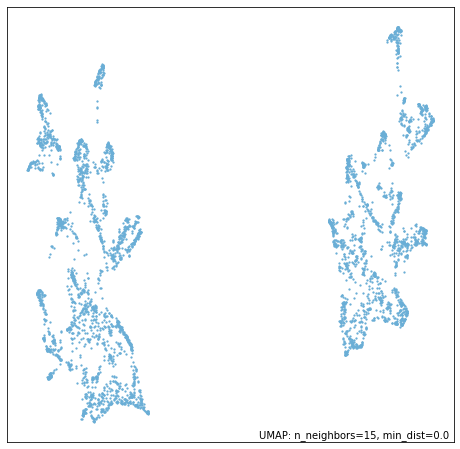

In [6]:
distances = get_gower(df[all], catogs)
emb_2d = umap.UMAP(n_components = 2, random_state = 42, min_dist=0.0).fit(distances)
umap.plot.points(emb_2d)

100%|██████████| 11/11 [00:22<00:00,  2.00s/it]

    min_sample  min_cluster cluster_selection     metric  num_clusters  \
28           5          400               eom  euclidean             2   
36           5          500               eom  euclidean             2   
32           5          450               eom  euclidean             2   
37           5          500               eom  manhattan             2   
33           5          450               eom  manhattan             2   

    unclustered_prop      dbcv  
28               0.0  0.931068  
36               0.0  0.931068  
32               0.0  0.931068  
37               0.0  0.930412  
33               0.0  0.930412  


<Axes: >

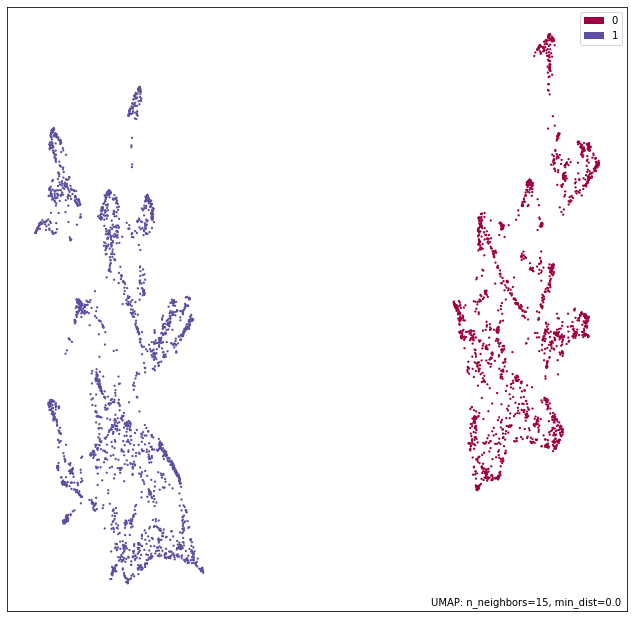

In [7]:
clusterer_2d = GenerateHDBSCAN(emb_2d.embedding_)
clusterer_2d.hdb()
c_2d = clusterer_2d.get_clusterer()
umap.plot.points(emb_2d, labels=c_2d.labels_)

In [8]:
df['labels_2d'] = c_2d.labels_